In [32]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import Bucketizer

In [33]:
spark = SparkSession.builder \
    .appName("Segmentacion_Perfilado_Clientes") \
    .getOrCreate()

clientes_df = spark.read.parquet("/home/jovyan/work/data/CLIENTS_CLEAN", header=True, inferSchema=True)
behavioural_df = spark.read.parquet("/home/jovyan/work/data/BEHAVIOURAL_CLEAN", header=True, inferSchema=True)

only_clientes_df = spark.read.parquet("/home/jovyan/work/data/SOLO_CLIENTS", header=True, inferSchema=True)
only_behavioural_df = spark.read.parquet("/home/jovyan/work/data/SOLO_BEHAVIOURAL", header=True, inferSchema=True)

comunes_df = spark.read.parquet("/home/jovyan/work/data/COMUNES", header=True, inferSchema=True)

# MÉTRICAS

## Clientes Prime

In [ ]:
#CAQ : Customer Acquisition Quality

# Creación del Dataframe con todos los datos de todos los clientes comunes
df_id_clientes_behavioural = clientes_df.join(
    behavioural_df,
    on="CLIENT_ID",
    how="inner"
)

# Cálculo del Payment Ratio (Pago / Saldo Pendiente)
df_features = df_id_clientes_behavioural.withColumn(
    "PAYMENT_RATIO",
    F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE")
)

# Maneje de Nulls/Division por Cero (CORREGIDO el error lógico)
# Aseguramos que (F.col("CREDICT_CARD_BALANCE") == 0) sea una expresión BOOLEAN
df_features = df_features.withColumn(
    "PAYMENT_RATIO",
    F.when(
        (F.col("PAYMENT_RATIO").isNull()) | (F.col("CREDICT_CARD_BALANCE") == 0), 1.0
    ).otherwise(F.col("PAYMENT_RATIO"))
)

# Cálculo de Umbrales (Q75) - Usando TOTAL_INCOME
quantile_list = [0.75]

quantiles = df_features.approxQuantile(
    ["TOTAL_INCOME", "CREDIT_CARD_LIMIT", "PAYMENT_RATIO"], 
    quantile_list,
    0.01
)

# Extracción de los umbrales
income_q75 = quantiles[0][0]
limit_q75 = quantiles[1][0]
ratio_q75 = quantiles[2][0]

print(f"Umbral de Ingreso (Q75): {income_q75:,.2f}")
print(f"Umbral de Límite (Q75): {limit_q75:,.2f}")
print(f"Umbral de Ratio de Pago (Q75): {ratio_q75:,.2f}")

# Filtrado y segmentación del Perfil CAQ
df_caq_profile = df_features.filter(
    (F.col("TOTAL_INCOME") >= income_q75) &           # Ingresos Altos
    (F.col("CREDIT_CARD_LIMIT") >= limit_q75) &       # Límites Altos
    (F.col("PAYMENT_RATIO") >= 1.0)                   # Sin Atrasos (Pagan al menos el 100% de la deuda)
)

print(f"Total de clientes en el perfil CAQ: {df_caq_profile.count()}")
df_caq_profile.show(5)

print("Porcentaje de clientes en el perfil CAQ:")
total_clients = clientes_df.select("CLIENT_ID").distinct().count()
caq_clients = df_caq_profile.select("CLIENT_ID").distinct().count()
percentage_caq = (caq_clients / total_clients) * 100
print(f"{percentage_caq:.2f}% de los clientes totales están en el perfil CAQ.")

Umbral de Ingreso (Q75): 2,700.00
Umbral de Límite (Q75): 2,160.00
Umbral de Ratio de Pago (Q75): 1.00
Total de clientes en el perfil CAQ: 80907
+------------+----------------------+-----------------+------+------------+--------------+-----------+---------+--------------+--------------+------------+-----------------+-------------+--------------+-----------+-----------------+-----------+------------------+------------------+---------------------+------------------+----------+--------------+----------+--------------------------+---------------------+------------------------+------------------------+------------------------+---------------------------+---------------------------+---------------------------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+-------------------+---------------------+-----------------+-------------------+----------------+------------------+----------+--------------------+-----------------+---

## Clientes NO prime

In [35]:
# Definición de los cuantiles a calcular (el 25%)
quantile_list_25 = [0.25]

# Cálculo de los cuantiles de las métricas clave (Q25)
quantiles_25 = df_features.approxQuantile(
    ["TOTAL_INCOME", "CREDIT_CARD_LIMIT", "PAYMENT_RATIO"], 
    quantile_list_25,
    0.01 
)

# Extracción de los umbrales Q25
income_q25 = quantiles_25[0][0]
limit_q25 = quantiles_25[1][0]
ratio_q25 = quantiles[2][0]

print(f"Umbral de Ingreso (Q25): {income_q25:,.2f}")
print(f"Umbral de Límite (Q25): {limit_q25:,.2f}")
print(f"Umbral de Ratio de Pago (Q25): {ratio_q25:,.2f}")

# Filtrado y segmentación del Perfil Q25 (Bajo)
df_perfil_q25 = df_features.filter(
    (F.col("TOTAL_INCOME") <= income_q25) &           # Ingresos Bajos (Bottom 25%)
    (F.col("CREDIT_CARD_LIMIT") <= limit_q25) &       # Límites Bajos (Bottom 25%)
    (F.col("PAYMENT_RATIO") < 1.0)                    # Riesgo Alto (Están revolviendo deuda)
)

# Cuantificar y mostrar
num_clientes_perfil_q25 = df_perfil_q25.select("CLIENT_ID").distinct().count()

print(f"\nNúmero total de clientes únicos en el Perfil Q25 (Bajo): {num_clientes_perfil_q25}")

df_perfil_q25.show(5)

print("Porcentaje de clientes en el perfil Q25 (Bajo):")
total_clients = clientes_df.select("CLIENT_ID").distinct().count()
caq_clients = df_perfil_q25.select("CLIENT_ID").distinct().count()
percentage_caq = (caq_clients / total_clients) * 100
print(f"{percentage_caq:.2f}% de los clientes totales están en el perfil Q25 (Bajo).")

Umbral de Ingreso (Q25): 1,350.00
Umbral de Límite (Q25): 540.00
Umbral de Ratio de Pago (Q25): 1.00

Número total de clientes únicos en el Perfil Q25 (Bajo): 1498
+------------+----------------------+-----------------+------+------------+--------------+-----------+---------+--------------+--------------+------------+-----------------+-------------+--------------+-----------+-----------------+-----------+------------------+------------------+---------------------+------------------+----------+--------------+----------+--------------------------+---------------------+------------------------+------------------------+------------------------+---------------------------+---------------------------+---------------------------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+-------------------+---------------------+-----------------+-------------------+----------------+------------------+----------+--------------------+--

## Estudio demográfico de los cuartiles

In [36]:
# Columnas demográficas
DEMO_COLS = ["GENDER", "MARITAL_STATUS", "AGE_IN_YEARS", "FAMILY_SIZE", "EDUCATION", "HOME_SITUATION", "JOB_SENIORITY", "HOME_SENIORITY"]

# Clientes Q75 (Alto) únicos
df_q75_unique = df_caq_profile.select(*DEMO_COLS).distinct() \
    .withColumn("Segmento", F.lit("Q75_ALTO"))

# Clientes Q25 (Bajo) únicos
df_q25_unique = df_perfil_q25.select(*DEMO_COLS).distinct() \
    .withColumn("Segmento", F.lit("Q25_BAJO"))

# Unión de los dos DataFrames
df_comparison = df_q75_unique.unionByName(df_q25_unique)

print("DataFrame de comparación creado. Total de clientes para comparar:")
df_comparison.groupBy("Segmento").count().show()

# Comienzo de los análisis demográficos

# ANÁLISIS EDAD
df_age_analysis = df_comparison.groupBy("Segmento").agg(
    F.avg("AGE_IN_YEARS").alias("Edad_Media"),
    F.min("AGE_IN_YEARS").alias("Edad_Min"),
    F.max("AGE_IN_YEARS").alias("Edad_Max"),
    F.stddev("AGE_IN_YEARS").alias("Desv_Estandar")
).select(
    "Segmento", 
    F.round("Edad_Media", 1).alias("Edad_Media"),
    F.col("Edad_Min"),
    F.col("Edad_Max"),
    F.round("Desv_Estandar", 1).alias("Desv_Estandar")
).orderBy("Segmento")

print("\nAnálisis Demográfico: Edad")
df_age_analysis.show()

# ANÁLISIS GÉNERO
total_counts = df_comparison.groupBy("Segmento").count().withColumnRenamed("count", "Total_Segmento")

df_gender_analysis = df_comparison.groupBy("Segmento", "GENDER").count() \
    .join(total_counts, on="Segmento") \
    .withColumn("Porcentaje", (F.col("count") / F.col("Total_Segmento")) * 100) \
    .select("Segmento", "GENDER", F.round("Porcentaje", 2).alias("Porcentaje")) \
    .orderBy("Segmento", F.desc("Porcentaje"))

print("\nAnálisis Demográfico: Distribución por Género")
df_gender_analysis.show()

# Asumimos que total_counts ya fue calculado en el paso anterior (Total_Segmento por segmento)

# ANÁLISIS EDUCACIÓN
df_education_analysis = df_comparison.groupBy("Segmento", "EDUCATION").count() \
    .join(total_counts, on="Segmento") \
    .withColumn("Porcentaje", (F.col("count") / F.col("Total_Segmento")) * 100) \
    .select("Segmento", "EDUCATION", F.round("Porcentaje", 2).alias("Porcentaje")) \
    .orderBy("Segmento", F.desc("Porcentaje"))

print("\nAnálisis Demográfico: Nivel de Estudios (EDUCATION)")
df_education_analysis.show(truncate=False)

# ANÁLISIS FAMILIA
df_family_size_analysis = df_comparison.groupBy("Segmento").agg(
    F.avg("FAMILY_SIZE").alias("FamilySize_Avg"),
    F.min("FAMILY_SIZE").alias("FamilySize_Min"),
    F.max("FAMILY_SIZE").alias("FamilySize_Max"),
    F.stddev("FAMILY_SIZE").alias("FamilySize_StdDev")
).select(
    "Segmento", 
    F.round("FamilySize_Avg", 2).alias("Tamaño_Familia_Media"),
    F.col("FamilySize_Min").alias("Tamaño_Familia_Min"),
    F.col("FamilySize_Max").alias("Tamaño_Familia_Max"),
    F.round("FamilySize_StdDev", 2).alias("Desv_Estandar")
).orderBy("Segmento")

print("\nAnálisis Demográfico: Tamaño de la Familia (FAMILY_SIZE)")
df_family_size_analysis.show()

DataFrame de comparación creado. Total de clientes para comparar:
+--------+-----+
|Segmento|count|
+--------+-----+
|Q75_ALTO| 6398|
|Q25_BAJO| 1497|
+--------+-----+


Análisis Demográfico: Edad
+--------+----------+------------------+-----------------+-------------+
|Segmento|Edad_Media|          Edad_Min|         Edad_Max|Desv_Estandar|
+--------+----------+------------------+-----------------+-------------+
|Q25_BAJO|      42.8|22.019178082191782|66.36986301369863|         11.2|
|Q75_ALTO|      44.0| 22.18082191780822|65.67123287671232|          9.4|
+--------+----------+------------------+-----------------+-------------+


Análisis Demográfico: Distribución por Género
+--------+------+----------+
|Segmento|GENDER|Porcentaje|
+--------+------+----------+
|Q25_BAJO|     F|     80.16|
|Q25_BAJO|     M|     19.84|
|Q75_ALTO|     F|      56.5|
|Q75_ALTO|     M|      43.5|
+--------+------+----------+


Análisis Demográfico: Nivel de Estudios (EDUCATION)
+--------+---------------------

## Utilización de crédito

In [ ]:
#CUR : Credit Utilization Ratio

# Cáculo de CUR = Balance / Límite
df_features = df_features.withColumn(
    "CUR", 
    F.when(
        F.col("CREDIT_CARD_LIMIT") > 0,
        F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
    ).otherwise(None)
)

# Cálculo de estadísticas básicas del CUR
cur_stats = df_features.select(
    F.count("CUR").alias("total_con_datos"),
    F.mean("CUR").alias("promedio_cur"),
    F.stddev("CUR").alias("desviacion_cur"),
    F.min("CUR").alias("min_cur"),
    F.max("CUR").alias("max_cur"),
    F.count(F.when(F.col("CUR").isNull(), 1)).alias("total_nulos")
)

# Mostrar estadísticas
cur_stats.show(truncate=False)

# Categorizamos CUR en niveles de riesgo (umbrales fijos)
df_features = df_features.withColumn(
    "CUR_RISK_LEVEL",
    F.when(F.col("CUR") >= 0.8, "MUY ALTO")      # ≥80%: Riesgo muy alto
    .when(F.col("CUR") >= 0.5, "ALTO")           # 50-79%: Riesgo alto  
    .when(F.col("CUR") >= 0.3, "MEDIO")          # 30-49%: Riesgo medio
    .when(F.col("CUR") >= 0.1, "BAJO")           # 10-29%: Riesgo bajo
    .when(F.col("CUR") >= 0, "MUY BAJO")         # 0-9%: Riesgo muy bajo
    .otherwise("SIN DATOS")                      # Nulos
)

# Contamos clientes por nivel de riesgo CUR
df_cur_risk_counts = df_features.groupBy("CUR_RISK_LEVEL").agg(
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("CUR").alias("PROMEDIO_CUR"),
    F.min("CUR").alias("MIN_CUR"),
    F.max("CUR").alias("MAX_CUR")
).orderBy(F.desc("NUM_CLIENTES"))

print("\nDistribución de clientes por nivel de riesgo CUR:")
df_cur_risk_counts.show(truncate=False)

# Filtramos clientes con CUR alto (≥50%)
df_clientes_cur_alto = df_features.filter(
    (F.col("CUR") >= 0.5) &  # CUR ≥ 50%
    (F.col("CUR").isNotNull())
)

num_clientes_cur_alto = df_clientes_cur_alto.select("CLIENT_ID").distinct().count()

print(f"\nNúmero de clientes con CUR ≥ 50% (alto riesgo): {num_clientes_cur_alto}")

# Mostramos algunos ejemplos
print("\nEjemplos de clientes con CUR alto (≥50%):")
df_clientes_cur_alto.select(
    "CLIENT_ID", 
    F.col("CREDICT_CARD_BALANCE").alias("CREDIT_CARD_BALANCE"),
    "CREDIT_CARD_LIMIT", 
    "CUR",
    "CUR_RISK_LEVEL"
).orderBy(F.desc("CUR")).show(10, truncate=False)

# Cálculo de porcentaje sobre total
total_clientes = df_features.select("CLIENT_ID").distinct().count()
porcentaje_cur_alto = (num_clientes_cur_alto / total_clientes) * 100
print(f"\nPorcentaje de clientes con CUR ≥ 50%: {porcentaje_cur_alto:.2f}%")

# CUR vs otras métricas
print("\nCUR promedio por segmento demográfico:")
df_features.groupBy("GENDER").agg(
    F.avg("CUR").alias("CUR_PROMEDIO"),
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES")
).show()

print("\nCUR promedio por tipo de ocupación:")
df_features.groupBy("OCCUPATION").agg(
    F.avg("CUR").alias("CUR_PROMEDIO"),
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES")
).orderBy(F.desc("CUR_PROMEDIO")).show()

+---------------+------------------+------------------+-------+-----------------+-----------+
|total_con_datos|promedio_cur      |desviacion_cur    |min_cur|max_cur          |total_nulos|
+---------------+------------------+------------------+-------+-----------------+-----------+
|1361841        |0.3849215780499086|0.4331750462041333|-1.8   |4.141074074074074|327093     |
+---------------+------------------+------------------+-------+-----------------+-----------+


Distribución de clientes por nivel de riesgo CUR:
+--------------+------------+---------------------+-------+----------------------+
|CUR_RISK_LEVEL|NUM_CLIENTES|PROMEDIO_CUR         |MIN_CUR|MAX_CUR               |
+--------------+------------+---------------------+-------+----------------------+
|MUY BAJO      |40582       |0.0021882542262930205|0.0    |0.09999814814814816   |
|MUY ALTO      |25362       |0.9666319344284158   |0.8    |4.141074074074074     |
|ALTO          |21834       |0.6642800977663846   |0.5    |0.79

In [38]:
# Cálculo de CUR promedio por cliente (un valor único)
df_cur_por_cliente = df_features.groupBy("CLIENT_ID").agg(
    F.avg(
        F.when(F.col("CREDIT_CARD_LIMIT") > 0,
               F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
        .otherwise(None)
    ).alias("CUR_PROMEDIO"),
    
    # También podemos calcular el CUR más reciente si tienes fecha
    F.max("CREDIT_CARD_LIMIT").alias("LIMIT_MAX"),
    F.avg("CREDICT_CARD_BALANCE").alias("BALANCE_PROMEDIO")
)

# Categorización CUR promedio por cliente
df_cur_por_cliente = df_cur_por_cliente.withColumn(
    "CUR_RISK_LEVEL",
    F.when(F.col("CUR_PROMEDIO") >= 0.8, "MUY ALTO")           # ≥80%
    .when(F.col("CUR_PROMEDIO") >= 0.6, "ALTO")                # 60-79%
    .when(F.col("CUR_PROMEDIO") >= 0.4, "MEDIO")               # 40-59%
    .when(F.col("CUR_PROMEDIO") >= 0.2, "BAJO")                # 20-39%
    .when(F.col("CUR_PROMEDIO") >= 0, "MUY BAJO")              # 0-19%
    .otherwise("SIN DATOS")                                    # Nulos
)

# Contamos CLIENTES ÚNICOS por nivel de riesgo
df_cur_counts_correcto = df_cur_por_cliente.groupBy("CUR_RISK_LEVEL").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES_UNICOS"),
    F.avg("CUR_PROMEDIO").alias("PROMEDIO_CUR"),
    F.min("CUR_PROMEDIO").alias("MIN_CUR"),
    F.max("CUR_PROMEDIO").alias("MAX_CUR")
).orderBy(
    F.when(F.col("CUR_RISK_LEVEL") == "MUY ALTO", 1)
     .when(F.col("CUR_RISK_LEVEL") == "ALTO", 2)
     .when(F.col("CUR_RISK_LEVEL") == "MEDIO", 3)
     .when(F.col("CUR_RISK_LEVEL") == "BAJO", 4)
     .when(F.col("CUR_RISK_LEVEL") == "MUY BAJO", 5)
     .otherwise(6)
)

print("\n" + "="*70)
print("DISTRIBUCIÓN CORREGIDA - CLIENTES ÚNICOS POR NIVEL DE RIESGO CUR")
print("="*70)
df_cur_counts_correcto.show(truncate=False)

# Cálculo de porcentajes correctos
total_clientes_unicos = df_cur_por_cliente.filter(
    F.col("CUR_RISK_LEVEL") != "SIN DATOS"
).count()

print(f"\nTotal clientes únicos con datos CUR: {total_clientes_unicos:,}")

print("\nPORCENTAJES (cada cliente cuenta solo una vez):")
for row in df_cur_counts_correcto.collect():
    nivel = row["CUR_RISK_LEVEL"]
    if nivel != "SIN DATOS":
        num_clientes = row["NUM_CLIENTES_UNICOS"]
        porcentaje = (num_clientes / total_clientes_unicos) * 100
        print(f"{nivel}: {num_clientes:,} clientes ({porcentaje:.1f}%)")

# Verificación de que la suma es 100%
suma_porcentajes = df_cur_counts_correcto.filter(
    F.col("CUR_RISK_LEVEL") != "SIN DATOS"
).select(F.sum("NUM_CLIENTES_UNICOS")).collect()[0][0]

print(f"\nSuma verificación: {suma_porcentajes:,} clientes")
print(f"Total clientes: {total_clientes_unicos:,} clientes")
print(f"Coincide: {suma_porcentajes == total_clientes_unicos}")

# Análisis de alto riesgo
alto_muy_alto = df_cur_por_cliente.filter(
    F.col("CUR_RISK_LEVEL").isin(["ALTO", "MUY ALTO"])
).count()

porcentaje_alto_riesgo = (alto_muy_alto / total_clientes_unicos) * 100

print(f"\nClientes con CUR ≥ 60% (Alto+Muy Alto riesgo): {alto_muy_alto:,}")
print(f"Porcentaje sobre total: {porcentaje_alto_riesgo:.1f}%")


DISTRIBUCIÓN CORREGIDA - CLIENTES ÚNICOS POR NIVEL DE RIESGO CUR
+--------------+-------------------+---------------------+--------------------+----------------------+
|CUR_RISK_LEVEL|NUM_CLIENTES_UNICOS|PROMEDIO_CUR         |MIN_CUR             |MAX_CUR               |
+--------------+-------------------+---------------------+--------------------+----------------------+
|MUY ALTO      |5601               |0.9059054613108516   |0.8000165343915344  |2.138789608227809     |
|ALTO          |5619               |0.7003222866570279   |0.6000399470899472  |0.7999895404663923    |
|MEDIO         |6320               |0.4976871617204468   |0.40002120236178207 |0.5998707502374168    |
|BAJO          |6955               |0.30020263255615603  |0.2000354938271605  |0.39996587132003786   |
|MUY BAJO      |20709              |0.029987501586400008 |0.0                 |0.19999767195767193   |
|SIN DATOS     |464                |-0.007713982716254257|-0.08484848484848484|-2.0576131687242797E-7|
+------

## Riesgo de moroso

In [39]:
# Definición de criterios de Riesgo de Moroso
df_rm = df_features.withColumn(
    "RM_INDICADOR",
    F.when(
        # Condición 1: CUR muy alto (≥80%)
        (F.col("CREDIT_CARD_LIMIT") > 0) & 
        (F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") >= 0.8), 1
    )
    .when(
        # Condición 2: Pago muy bajo comparado con balance (≤10%)
        (F.col("CREDICT_CARD_BALANCE") > 0) &
        (F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") <= 0.1), 1
    )
    .when(
        # Condición 3: Muchos retiros en cajeros (posible cash advance)
        (F.col("NUMBER_DRAWINGS_ATM") >= 10), 1
    )
    .when(
        # Condición 4: Historial de préstamos denegados
        (F.col("NUM_STATUS_DENIED") >= 3), 1
    )
    .when(
        # Condición 5: Incumplimiento de contrato actual
        (F.col("NON_COMPLIANT_CONTRACT") == 1), 1
    )
    .when(
        # Condición 6: Alto endeudamiento vs ingresos
        (F.col("TOTAL_INCOME") > 0) &
        (F.col("INSTALLMENT") / F.col("TOTAL_INCOME") >= 0.5), 1
    )
    .otherwise(0)
)

# Cálculo del score de riesgo de moroso (0-6 puntos)
df_rm = df_rm.withColumn(
    "RM_SCORE",
    (
        # Punto 1: CUR ≥ 80%
        F.when((F.col("CREDIT_CARD_LIMIT") > 0) & 
               (F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") >= 0.8), 1).otherwise(0) +
        
        # Punto 2: Pago ≤ 10% del balance
        F.when((F.col("CREDICT_CARD_BALANCE") > 0) &
               (F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") <= 0.1), 1).otherwise(0) +
        
        # Punto 3: ≥10 retiros en cajeros
        F.when(F.col("NUMBER_DRAWINGS_ATM") >= 10, 1).otherwise(0) +
        
        # Punto 4: ≥3 préstamos denegados
        F.when(F.col("NUM_STATUS_DENIED") >= 3, 1).otherwise(0) +
        
        # Punto 5: Incumplimiento de contrato
        F.when(F.col("NON_COMPLIANT_CONTRACT") == 1, 1).otherwise(0) +
        
        # Punto 6: Endeudamiento ≥ 50% de ingresos
        F.when((F.col("TOTAL_INCOME") > 0) &
               (F.col("INSTALLMENT") / F.col("TOTAL_INCOME") >= 0.5), 1).otherwise(0)
    )
)

# Categorización por nivel de riesgo de moroso
df_rm = df_rm.withColumn(
    "RM_NIVEL_RIESGO",
    F.when(F.col("RM_SCORE") >= 4, "RIESGO EXTREMO")
    .when(F.col("RM_SCORE") >= 3, "RIESGO ALTO")
    .when(F.col("RM_SCORE") >= 2, "RIESGO MODERADO")
    .when(F.col("RM_SCORE") == 1, "RIESGO BAJO")
    .otherwise("SIN RIESGO")
)

# 4. AGREGAR POR CLIENTE (para evitar duplicados)
df_rm_por_cliente = df_rm.groupBy("CLIENT_ID").agg(
    F.max("RM_INDICADOR").alias("RM_INDICADOR"),
    F.max("RM_SCORE").alias("RM_SCORE_MAX"),
    F.avg("RM_SCORE").alias("RM_SCORE_PROMEDIO"),
    F.count(F.when(F.col("RM_INDICADOR") == 1, 1)).alias("NUM_MESES_CON_RIESGO")
)

# Categorización por cliente (basado en el peor escenario)
df_rm_por_cliente = df_rm_por_cliente.withColumn(
    "RM_NIVEL_RIESGO_CLIENTE",
    F.when(F.col("RM_INDICADOR") == 0, "SIN RIESGO")
    .when(F.col("RM_SCORE_MAX") >= 4, "RIESGO EXTREMO")
    .when(F.col("RM_SCORE_MAX") >= 3, "RIESGO ALTO")
    .when(F.col("RM_SCORE_MAX") >= 2, "RIESGO MODERADO")
    .otherwise("RIESGO BAJO")
)

# ESTADÍSTICAS POR NIVEL DE RIESGO
print("\n" + "="*70)
print("ANÁLISIS DE RIESGO DE MOROSO (RM) - POR CLIENTE")
print("="*70)

df_rm_stats = df_rm_por_cliente.groupBy("RM_NIVEL_RIESGO_CLIENTE").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("RM_SCORE_PROMEDIO").alias("SCORE_PROMEDIO"),
    F.avg("NUM_MESES_CON_RIESGO").alias("MESES_RIESGO_PROMEDIO")
).orderBy(
    F.when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO EXTREMO", 1)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO ALTO", 2)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO MODERADO", 3)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO BAJO", 4)
     .otherwise(5)
)

df_rm_stats.show(truncate=False)

# PORCENTAJES
total_clientes_rm = df_rm_por_cliente.count()
print(f"\nTotal clientes analizados: {total_clientes_rm:,}")

print("\nDISTRIBUCIÓN PORCENTUAL:")
for row in df_rm_stats.collect():
    nivel = row["RM_NIVEL_RIESGO_CLIENTE"]
    num_clientes = row["NUM_CLIENTES"]
    porcentaje = (num_clientes / total_clientes_rm) * 100
    print(f"{nivel}: {num_clientes:,} clientes ({porcentaje:.1f}%)")

# CLIENTES EN RIESGO EXTREMO/ALTO (prioridad)
clientes_alto_riesgo = df_rm_por_cliente.filter(
    F.col("RM_NIVEL_RIESGO_CLIENTE").isin(["RIESGO EXTREMO", "RIESGO ALTO"])
).count()

porcentaje_alto_riesgo = (clientes_alto_riesgo / total_clientes_rm) * 100
print(f"\nClientes en RIESGO ALTO/EXTREMO: {clientes_alto_riesgo:,} ({porcentaje_alto_riesgo:.1f}%)")

# EJEMPLOS DE CLIENTES EN RIESGO EXTREMO
print("\n" + "="*70)
print("EJEMPLOS DE CLIENTES EN RIESGO EXTREMO")
print("="*70)

df_ejemplos_extremo = df_rm.filter(F.col("RM_NIVEL_RIESGO") == "RIESGO EXTREMO") \
    .select(
        "CLIENT_ID",
        F.round(
            F.when(
                F.col("CREDIT_CARD_LIMIT") > 0,
                F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") * 100
            ).otherwise(0),
            1
        ).alias("CUR_%"),
        F.round(
            F.when(
                F.col("CREDICT_CARD_BALANCE") > 0,
                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") * 100
            ).otherwise(0),
            1
        ).alias("PAGO_VS_BALANCE_%"),
        F.round(
            F.when(
                F.col("TOTAL_INCOME") > 0,
                F.col("INSTALLMENT") / F.col("TOTAL_INCOME") * 100
            ).otherwise(0),
            1
        ).alias("DEUDA_VS_INGRESOS_%"),
        "NUM_STATUS_DENIED",
        "NON_COMPLIANT_CONTRACT",
        "NUMBER_DRAWINGS_ATM",
        "RM_SCORE",
        "RM_NIVEL_RIESGO"
    ) \
    .distinct() \
    .orderBy(F.desc("RM_SCORE")) \
    .limit(10)

df_ejemplos_extremo.show(truncate=False)

# ANÁLISIS CRUZADO CON CUR
print("\n" + "="*70)
print("ANÁLISIS CRUZADO: CUR vs RIESGO DE MOROSO")
print("="*70)

df_cur_cliente = df_features.withColumn(
    "CUR_CLIENTE",
    F.when(
        F.col("CREDIT_CARD_LIMIT") > 0,
        F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
    ).otherwise(None)
).groupBy("CLIENT_ID").agg(
    F.avg("CUR_CLIENTE").alias("CUR_PROMEDIO")
)

df_rm_con_cur = df_rm_por_cliente.join(df_cur_cliente, on="CLIENT_ID", how="left")

df_rm_con_cur = df_rm_con_cur.withColumn(
    "CUR_CATEGORIA",
    F.when(F.col("CUR_PROMEDIO") >= 0.8, "MUY ALTO")
    .when(F.col("CUR_PROMEDIO") >= 0.6, "ALTO")
    .when(F.col("CUR_PROMEDIO") >= 0.4, "MEDIO")
    .when(F.col("CUR_PROMEDIO") >= 0.2, "BAJO")
    .when(F.col("CUR_PROMEDIO") >= 0, "MUY BAJO")
    .otherwise("SIN DATOS")
)

df_cruzado_rm_cur = df_rm_con_cur.groupBy("RM_NIVEL_RIESGO_CLIENTE", "CUR_CATEGORIA") \
    .agg(F.count("CLIENT_ID").alias("NUM_CLIENTES")) \
    .orderBy("RM_NIVEL_RIESGO_CLIENTE", 
             F.when(F.col("CUR_CATEGORIA") == "MUY ALTO", 1)
              .when(F.col("CUR_CATEGORIA") == "ALTO", 2)
              .when(F.col("CUR_CATEGORIA") == "MEDIO", 3)
              .when(F.col("CUR_CATEGORIA") == "BAJO", 4)
              .when(F.col("CUR_CATEGORIA") == "MUY BAJO", 5)
              .otherwise(6))

print("\nDistribución CUR vs Riesgo de Moroso:")
df_cruzado_rm_cur.show(truncate=False)


ANÁLISIS DE RIESGO DE MOROSO (RM) - POR CLIENTE
+-----------------------+------------+------------------+---------------------+
|RM_NIVEL_RIESGO_CLIENTE|NUM_CLIENTES|SCORE_PROMEDIO    |MESES_RIESGO_PROMEDIO|
+-----------------------+------------+------------------+---------------------+
|RIESGO EXTREMO         |1145        |2.8401504698590645|33.570305676855895   |
|RIESGO ALTO            |6571        |1.89407443465335  |38.90381981433572    |
|RIESGO MODERADO        |18273       |0.9172886225346794|22.784162425436435   |
|RIESGO BAJO            |7143        |0.5315531740882301|11.479490410191795   |
|SIN RIESGO             |12536       |0.0               |0.0                  |
+-----------------------+------------+------------------+---------------------+


Total clientes analizados: 45,668

DISTRIBUCIÓN PORCENTUAL:
RIESGO EXTREMO: 1,145 clientes (2.5%)
RIESGO ALTO: 6,571 clientes (14.4%)
RIESGO MODERADO: 18,273 clientes (40.0%)
RIESGO BAJO: 7,143 clientes (15.6%)
SIN RIESGO: 12,536

## Engagement Score (clientes activos vs inactivos)

In [40]:
print("="*100)
print("ANÁLISIS COMPLETO DE ENGAGEMENT DEL CLIENTE - 3 DIMENSIONES")
print("="*100)
print("Dimensiones: 1. Variedad de Uso | 2. Intensidad de Uso | 3. Hábitos Saludables")
print("="*100)


# PRIMERO: VERIFICAR QUE TENEMOS LOS DATOS NECESARIOS

print("\n1. VERIFICACIÓN DE DATOS DISPONIBLES")
print("-"*60)

# Verificar columnas disponibles en df_features
columnas_necesarias = [
    "CLIENT_ID",
    "CREDIT_CARD_DRAWINGS_ATM",
    "CREDIT_CARD_DRAWINGS_POS", 
    "CREDIT_CARD_DRAWINGS_OTHER",
    "CREDIT_CARD_DRAWINGS",
    "CREDIT_CARD_PAYMENT",
    "CREDICT_CARD_BALANCE",
    "CREDIT_CARD_LIMIT",
    "NUMBER_INSTALMENTS"
]

columnas_faltantes = [col for col in columnas_necesarias if col not in df_features.columns]

if columnas_faltantes:
    print(f" ADVERTENCIA: Faltan columnas: {columnas_faltantes}")
    print("   El análisis puede estar incompleto.")
else:
    print(" Todas las columnas necesarias están disponibles")

print(f"\nTotal de registros en df_features: {df_features.count():,}")
print(f"Total de clientes únicos: {df_features.select('CLIENT_ID').distinct().count():,}")


# ENGAGEMENT POR VARIEDAD DE USO

print("\n" + "="*100)
print("DIMENSIÓN 1: VARIEDAD DE USO")
print("(Mide cuántos tipos diferentes de servicios usa el cliente)")
print("="*100)

df_variedad = df_features.groupBy("CLIENT_ID").agg(
    # 1.1 Variedad de tipos de transacción (cuántos tipos diferentes usa)
    F.countDistinct(
        "CREDIT_CARD_DRAWINGS_ATM", 
        "CREDIT_CARD_DRAWINGS_POS", 
        "CREDIT_CARD_DRAWINGS_OTHER"
    ).alias("VARIEDAD_TIPO_TRANSACCION"),
    
    # 1.2 Uso de diferentes canales (ATM, POS, Otros)
    F.when(F.sum("CREDIT_CARD_DRAWINGS_ATM") > 0, 1).otherwise(0).alias("USA_ATM"),
    F.when(F.sum("CREDIT_CARD_DRAWINGS_POS") > 0, 1).otherwise(0).alias("USA_POS"),
    F.when(F.sum("CREDIT_CARD_DRAWINGS_OTHER") > 0, 1).otherwise(0).alias("USA_OTHER"),
    
    # 1.3 Profundidad de uso (monto promedio por transacción)
    F.avg("CREDIT_CARD_DRAWINGS").alias("MONTO_PROMEDIO_TRANSACCION"),
    
    # 1.4 Consistencia en pagos (qué % de su balance paga)
    F.when(F.sum("CREDICT_CARD_BALANCE") > 0,
           F.sum("CREDIT_CARD_PAYMENT") / F.sum("CREDICT_CARD_BALANCE"))
     .otherwise(0).alias("RATIO_PAGO_VS_BALANCE")
)

# Calcular Score de Variedad (0-100 puntos)
df_variedad = df_variedad.withColumn(
    "SCORE_VARIEDAD",
    # Puntos por variedad de tipos (máx 25 puntos)
    (F.col("VARIEDAD_TIPO_TRANSACCION") / 3 * 25) +  
    
    # Puntos por uso de diferentes canales (máx 25 puntos)
    ((F.col("USA_ATM") + F.col("USA_POS") + F.col("USA_OTHER")) * 25) +  
    
    # Puntos por monto promedio de transacción (máx 25 puntos)
    (F.when(F.col("MONTO_PROMEDIO_TRANSACCION") > 100, 25)
      .when(F.col("MONTO_PROMEDIO_TRANSACCION") > 50, 15)
      .when(F.col("MONTO_PROMEDIO_TRANSACCION") > 10, 5)
      .otherwise(0)) +  
    
    # Puntos por ratio de pago (máx 25 puntos)
    (F.when(F.col("RATIO_PAGO_VS_BALANCE") >= 0.8, 25)
      .when(F.col("RATIO_PAGO_VS_BALANCE") >= 0.5, 15)
      .when(F.col("RATIO_PAGO_VS_BALANCE") > 0, 5)
      .otherwise(0))
)

# Clasificar por nivel de variedad
df_variedad = df_variedad.withColumn(
    "NIVEL_VARIEDAD",
    F.when(F.col("SCORE_VARIEDAD") >= 75, "ALTA VARIEDAD")
     .when(F.col("SCORE_VARIEDAD") >= 50, "MEDIA VARIEDAD")
     .when(F.col("SCORE_VARIEDAD") >= 25, "BAJA VARIEDAD")
     .otherwise("SIN VARIEDAD")
)

print(f" Variedad calculada para {df_variedad.count():,} clientes")


# ENGAGEMENT POR INTENSIDAD DE USO

print("\n" + "="*100)
print("DIMENSIÓN 2: INTENSIDAD DE USO")
print("(Mide cuánto y cómo de intensamente usa los servicios)")
print("="*100)

df_intensidad = df_features.groupBy("CLIENT_ID").agg(
    # 2.1 Utilización del crédito disponible (% del límite usado)
    F.when(F.avg("CREDIT_CARD_LIMIT") > 0,
           F.avg("CREDICT_CARD_BALANCE") / F.avg("CREDIT_CARD_LIMIT"))
     .otherwise(0).alias("UTILIZACION_PROMEDIO"),
    
    # 2.2 Intensidad de transacciones (monto promedio por uso)
    F.avg("CREDIT_CARD_DRAWINGS").alias("MONTO_PROMEDIO_USO"),
    
    # 2.3 Comportamiento de pago (qué % del balance paga)
    F.when(F.sum("CREDICT_CARD_BALANCE") > 0,
           F.sum("CREDIT_CARD_PAYMENT") / F.sum("CREDICT_CARD_BALANCE"))
     .otherwise(0).alias("RATIO_PAGO"),
    
    # 2.4 Uso de pagos fraccionados
    F.when(F.count("*") > 0,
           F.sum("NUMBER_INSTALMENTS") / F.count("*"))
     .otherwise(0).alias("FRACCION_PAGOS_FRACCIONADOS")
)

# Calcular Score de Intensidad (0-100 puntos)
df_intensidad = df_intensidad.withColumn(
    "SCORE_INTENSIDAD",
    # Puntos por utilización óptima (30-70% es ideal) - máx 30 puntos
    F.when((F.col("UTILIZACION_PROMEDIO") >= 0.3) & (F.col("UTILIZACION_PROMEDIO") <= 0.7), 30)
     .when(F.col("UTILIZACION_PROMEDIO") > 0, 15)
     .otherwise(0) +
    
    # Puntos por monto promedio de uso - máx 30 puntos
    F.when(F.col("MONTO_PROMEDIO_USO") >= 500, 30)
     .when(F.col("MONTO_PROMEDIO_USO") >= 200, 20)
     .when(F.col("MONTO_PROMEDIO_USO") >= 50, 10)
     .otherwise(5) +
    
    # Puntos por ratio de pago saludable - máx 40 puntos
    F.when(F.col("RATIO_PAGO") >= 0.8, 40)
     .when(F.col("RATIO_PAGO") >= 0.5, 25)
     .when(F.col("RATIO_PAGO") > 0, 10)
     .otherwise(0)
)

# Clasificar por nivel de intensidad
df_intensidad = df_intensidad.withColumn(
    "NIVEL_INTENSIDAD",
    F.when(F.col("SCORE_INTENSIDAD") >= 80, "USO INTENSO")
     .when(F.col("SCORE_INTENSIDAD") >= 50, "USO MODERADO")
     .when(F.col("SCORE_INTENSIDAD") >= 20, "USO OCASIONAL")
     .otherwise("USO MÍNIMO")
)

print(f" Intensidad calculada para {df_intensidad.count():,} clientes")


# ENGAGEMENT POR HÁBITOS SALUDABLES

print("\n" + "="*100)
print("DIMENSIÓN 3: HÁBITOS SALUDABLES")
print("(Mide la salud financiera de los hábitos del cliente)")
print("="*100)

df_habitos = df_features.groupBy("CLIENT_ID").agg(
    # 3.1 Paga más del mínimo (% del balance que paga)
    F.when(F.avg("CREDICT_CARD_BALANCE") > 0,
           F.avg("CREDIT_CARD_PAYMENT") / F.avg("CREDICT_CARD_BALANCE"))
     .otherwise(0).alias("RATIO_PAGO_SOBRE_BALANCE"),
    
    # 3.2 No abusa del cash advance (% de uso en ATM)
    F.when(F.sum("CREDIT_CARD_DRAWINGS") > 0,
           F.sum("CREDIT_CARD_DRAWINGS_ATM") / F.sum("CREDIT_CARD_DRAWINGS"))
     .otherwise(0).alias("PORCENTAJE_USO_ATM"),
    
    # 3.3 Usa crédito para compras (% de uso en POS)
    F.when(F.sum("CREDIT_CARD_DRAWINGS") > 0,
           F.sum("CREDIT_CARD_DRAWINGS_POS") / F.sum("CREDIT_CARD_DRAWINGS"))
     .otherwise(0).alias("PORCENTAJE_USO_POS"),
    
    # 3.4 Mantiene balance manejable (% del límite usado)
    F.when(F.avg("CREDIT_CARD_LIMIT") > 0,
           F.avg("CREDICT_CARD_BALANCE") / F.avg("CREDIT_CARD_LIMIT"))
     .otherwise(0).alias("UTILIZACION_CREDITO"),
    
    # 3.5 No abusa de pagos fraccionados
    F.avg("NUMBER_INSTALMENTS").alias("PROMEDIO_INSTALMENTS")
)

# Calcular Score de Hábitos Saludables (0-100 puntos)
df_habitos = df_habitos.withColumn(
    "SCORE_HABITOS_SALUDABLES",
    # Puntos por buen ratio de pago - máx 30 puntos
    F.when(F.col("RATIO_PAGO_SOBRE_BALANCE") >= 0.8, 30)
     .when(F.col("RATIO_PAGO_SOBRE_BALANCE") >= 0.5, 20)
     .when(F.col("RATIO_PAGO_SOBRE_BALANCE") > 0.2, 10)
     .otherwise(0) +
    
    # Puntos por uso diversificado (no solo ATM) - máx 20 puntos
    F.when(F.col("PORCENTAJE_USO_ATM") < 0.3, 20)
     .when(F.col("PORCENTAJE_USO_ATM") < 0.6, 10)
     .otherwise(0) +
    
    # Puntos por uso para compras (POS) - máx 20 puntos
    F.when(F.col("PORCENTAJE_USO_POS") > 0.5, 20)
     .when(F.col("PORCENTAJE_USO_POS") > 0.2, 10)
     .otherwise(0) +
    
    # Puntos por utilización saludable (30-70%) - máx 20 puntos
    F.when((F.col("UTILIZACION_CREDITO") >= 0.3) & (F.col("UTILIZACION_CREDITO") <= 0.7), 20)
     .when(F.col("UTILIZACION_CREDITO") < 0.9, 10)
     .otherwise(0) +
    
    # Puntos por no abusar de pagos fraccionados - máx 10 puntos
    F.when(F.col("PROMEDIO_INSTALMENTS") < 2, 10)
     .when(F.col("PROMEDIO_INSTALMENTS") < 4, 5)
     .otherwise(0)
)

# Clasificar por nivel de hábitos
df_habitos = df_habitos.withColumn(
    "NIVEL_HABITOS",
    F.when(F.col("SCORE_HABITOS_SALUDABLES") >= 80, "HÁBITOS EXCELENTES")
     .when(F.col("SCORE_HABITOS_SALUDABLES") >= 60, "HÁBITOS BUENOS")
     .when(F.col("SCORE_HABITOS_SALUDABLES") >= 40, "HÁBITOS REGULARES")
     .otherwise("HÁBITOS A MEJORAR")
)

print(f" Hábitos calculados para {df_habitos.count():,} clientes")


# COMBINAR LOS 3 SCORES - ENGAGEMENT COMPLETO

print("\n" + "="*100)
print("COMBINACIÓN: ENGAGEMENT SCORE COMPLETO")
print("(Score total ponderado: 30% Variedad + 40% Intensidad + 30% Hábitos)")
print("="*100)

# Unir todos los DataFrames
df_engagement_completo = df_variedad.join(
    df_intensidad, on="CLIENT_ID", how="inner"
).join(
    df_habitos, on="CLIENT_ID", how="inner"
)

# Calcular Score Total (promedio ponderado)
df_engagement_completo = df_engagement_completo.withColumn(
    "ENGAGEMENT_SCORE_TOTAL",
    (F.col("SCORE_VARIEDAD") * 0.3) +    # 30% peso para Variedad
    (F.col("SCORE_INTENSIDAD") * 0.4) +  # 40% peso para Intensidad
    (F.col("SCORE_HABITOS_SALUDABLES") * 0.3)  # 30% peso para Hábitos
)

# Clasificar por nivel total de Engagement
df_engagement_completo = df_engagement_completo.withColumn(
    "NIVEL_ENGAGEMENT_TOTAL",
    F.when(F.col("ENGAGEMENT_SCORE_TOTAL") >= 80, "ENGAGEMENT ALTO")
     .when(F.col("ENGAGEMENT_SCORE_TOTAL") >= 60, "ENGAGEMENT MEDIO-ALTO")
     .when(F.col("ENGAGEMENT_SCORE_TOTAL") >= 40, "ENGAGEMENT MEDIO")
     .when(F.col("ENGAGEMENT_SCORE_TOTAL") >= 20, "ENGAGEMENT BAJO")
     .otherwise("ENGAGEMENT MUY BAJO")
)


# RESULTADOS Y ESTADÍSTICAS

print("\n" + "="*100)
print("RESULTADOS FINALES")
print("="*100)

total_clientes = df_engagement_completo.count()
print(f"\n TOTAL CLIENTES ANALIZADOS: {total_clientes:,}")


# Distribución del Engagement Total

print("\n" + "-"*60)
print("1. DISTRIBUCIÓN DEL ENGAGEMENT TOTAL")
print("-"*60)

distribucion_total = []
for nivel in ["ENGAGEMENT ALTO", "ENGAGEMENT MEDIO-ALTO", "ENGAGEMENT MEDIO", 
              "ENGAGEMENT BAJO", "ENGAGEMENT MUY BAJO"]:
    count = df_engagement_completo.filter(F.col("NIVEL_ENGAGEMENT_TOTAL") == nivel).count()
    porcentaje = (count / total_clientes) * 100
    distribucion_total.append((nivel, count, porcentaje))
    print(f"   • {nivel}: {count:>6,} clientes ({porcentaje:5.1f}%)")


# Distribución por cada Dimensión

print("\n" + "-"*60)
print("2. DISTRIBUCIÓN POR DIMENSIÓN")
print("-"*60)

print("\n   A. VARIEDAD DE USO:")
for nivel in ["ALTA VARIEDAD", "MEDIA VARIEDAD", "BAJA VARIEDAD", "SIN VARIEDAD"]:
    count = df_engagement_completo.filter(F.col("NIVEL_VARIEDAD") == nivel).count()
    print(f"      • {nivel}: {count:,}")

print("\n   B. INTENSIDAD DE USO:")
for nivel in ["USO INTENSO", "USO MODERADO", "USO OCASIONAL", "USO MÍNIMO"]:
    count = df_engagement_completo.filter(F.col("NIVEL_INTENSIDAD") == nivel).count()
    print(f"      • {nivel}: {count:,}")

print("\n   C. HÁBITOS SALUDABLES:")
for nivel in ["HÁBITOS EXCELENTES", "HÁBITOS BUENOS", "HÁBITOS REGULARES", "HÁBITOS A MEJORAR"]:
    count = df_engagement_completo.filter(F.col("NIVEL_HABITOS") == nivel).count()
    print(f"      • {nivel}: {count:,}")


# Promedios de Scores

print("\n" + "-"*60)
print("3. PUNTUACIONES PROMEDIO")
print("-"*60)

stats = df_engagement_completo.agg(
    F.avg("ENGAGEMENT_SCORE_TOTAL").alias("PROMEDIO_TOTAL"),
    F.avg("SCORE_VARIEDAD").alias("PROMEDIO_VARIEDAD"),
    F.avg("SCORE_INTENSIDAD").alias("PROMEDIO_INTENSIDAD"),
    F.avg("SCORE_HABITOS_SALUDABLES").alias("PROMEDIO_HABITOS"),
    F.stddev("ENGAGEMENT_SCORE_TOTAL").alias("DESVIACION_TOTAL")
).collect()[0]

print(f"   • Engagement Total: {stats['PROMEDIO_TOTAL']:.1f}/100 (±{stats['DESVIACION_TOTAL']:.1f})")
print(f"   • Variedad: {stats['PROMEDIO_VARIEDAD']:.1f}/100")
print(f"   • Intensidad: {stats['PROMEDIO_INTENSIDAD']:.1f}/100")
print(f"   • Hábitos: {stats['PROMEDIO_HABITOS']:.1f}/100")


# Top Clientes por cada Dimensión

print("\n" + "-"*60)
print("4. TOP CLIENTES POR DIMENSIÓN")
print("-"*60)

print("\n   MEJORES EN VARIEDAD:")
df_engagement_completo.select(
    "CLIENT_ID",
    "NIVEL_VARIEDAD",
    F.round(F.col("SCORE_VARIEDAD"), 1).alias("SCORE"),
    "VARIEDAD_TIPO_TRANSACCION"
).orderBy(F.desc("SCORE_VARIEDAD")).limit(3).show(truncate=False)

print("\n   MEJORES EN INTENSIDAD:")
df_engagement_completo.select(
    "CLIENT_ID",
    "NIVEL_INTENSIDAD",
    F.round(F.col("SCORE_INTENSIDAD"), 1).alias("SCORE"),
    F.round(F.col("MONTO_PROMEDIO_USO"), 2).alias("MONTO_PROM")
).orderBy(F.desc("SCORE_INTENSIDAD")).limit(3).show(truncate=False)

print("\n   MEJORES EN HÁBITOS:")
df_engagement_completo.select(
    "CLIENT_ID",
    "NIVEL_HABITOS",
    F.round(F.col("SCORE_HABITOS_SALUDABLES"), 1).alias("SCORE"),
    F.round(F.col("RATIO_PAGO_SOBRE_BALANCE") * 100, 1).alias("PAGO_%")
).orderBy(F.desc("SCORE_HABITOS_SALUDABLES")).limit(3).show(truncate=False)


# Clientes Críticos (prioridad de acción)

print("\n" + "-"*60)
print("5. CLIENTES CRÍTICOS (PRIORIDAD)")
print("-"*60)

df_criticos = df_engagement_completo.filter(
    F.col("NIVEL_ENGAGEMENT_TOTAL").isin(["ENGAGEMENT MUY BAJO", "ENGAGEMENT BAJO"])
)

num_criticos = df_criticos.count()
print(f"\n   CLIENTES CRÍTICOS: {num_criticos:,} ({num_criticos/total_clientes*100:.1f}%)")

if num_criticos > 0:
    print("\n   Perfil típico del cliente crítico:")
    perfil_critico = df_criticos.agg(
        F.avg("SCORE_VARIEDAD").alias("VAR_PROM"),
        F.avg("SCORE_INTENSIDAD").alias("INT_PROM"),
        F.avg("SCORE_HABITOS_SALUDABLES").alias("HAB_PROM")
    ).collect()[0]
    
    print(f"      • Variedad: {perfil_critico['VAR_PROM']:.1f}/100")
    print(f"      • Intensidad: {perfil_critico['INT_PROM']:.1f}/100")
    print(f"      • Hábitos: {perfil_critico['HAB_PROM']:.1f}/100")
    
    print("\n   Ejemplos de clientes críticos:")
    df_criticos.select(
        "CLIENT_ID",
        "NIVEL_ENGAGEMENT_TOTAL",
        F.round(F.col("ENGAGEMENT_SCORE_TOTAL"), 1).alias("SCORE_TOTAL"),
        "NIVEL_VARIEDAD",
        "NIVEL_INTENSIDAD",
        "NIVEL_HABITOS"
    ).orderBy("ENGAGEMENT_SCORE_TOTAL").limit(5).show(truncate=False)

# Clientes Excelentes (fidelizar)

print("\n" + "-"*60)
print("6. CLIENTES EXCELENTES (FIDELIZAR)")
print("-"*60)

df_excelentes = df_engagement_completo.filter(
    F.col("NIVEL_ENGAGEMENT_TOTAL").isin(["ENGAGEMENT ALTO", "ENGAGEMENT MEDIO-ALTO"])
)

num_excelentes = df_excelentes.count()
print(f"\n   CLIENTES EXCELENTES: {num_excelentes:,} ({num_excelentes/total_clientes*100:.1f}%)")

if num_excelentes > 0:
    print("\n   Perfil típico del cliente excelente:")
    perfil_excelente = df_excelentes.agg(
        F.avg("SCORE_VARIEDAD").alias("VAR_PROM"),
        F.avg("SCORE_INTENSIDAD").alias("INT_PROM"),
        F.avg("SCORE_HABITOS_SALUDABLES").alias("HAB_PROM")
    ).collect()[0]
    
    print(f"      • Variedad: {perfil_excelente['VAR_PROM']:.1f}/100")
    print(f"      • Intensidad: {perfil_excelente['INT_PROM']:.1f}/100")
    print(f"      • Hábitos: {perfil_excelente['HAB_PROM']:.1f}/100")
    
    print("\n   Top 3 clientes excelentes:")
    df_excelentes.select(
        "CLIENT_ID",
        "NIVEL_ENGAGEMENT_TOTAL",
        F.round(F.col("ENGAGEMENT_SCORE_TOTAL"), 1).alias("SCORE_TOTAL"),
        "NIVEL_VARIEDAD",
        "NIVEL_INTENSIDAD",
        "NIVEL_HABITOS"
    ).orderBy(F.desc("ENGAGEMENT_SCORE_TOTAL")).limit(3).show(truncate=False)


# RECOMENDACIONES DE ACCIÓN

print("\n" + "="*100)
print("RECOMENDACIONES DE ACCIÓN POR SEGMENTO")
print("="*100)

print("\n RESUMEN DE SEGMENTACIÓN:")
print(f"   • Total clientes: {total_clientes:,}")
print(f"   • Excelentes (fidelizar): {num_excelentes:,} ({num_excelentes/total_clientes*100:.1f}%)")
print(f"   • Críticos (acción urgente): {num_criticos:,} ({num_criticos/total_clientes*100:.1f}%)")
print(f"   • Relación Excelente:Crítico = 1:{num_criticos/num_excelentes:.1f}")

print("\n ACCIONES RECOMENDADAS:")

print("\n   1. PARA CLIENTES CON VARIEDAD BAJA:")
print("      • Ofertar nuevos productos/servicios")
print("      • Campañas cross-selling")
print("      • Bonos por uso de múltiples servicios")

print("\n   2. PARA CLIENTES CON INTENSIDAD BAJA:")
print("      • Programas de recompensas por uso frecuente")
print("      • Límites de crédito progresivos")
print("      • Recordatorios de uso periódico")

print("\n   3. PARA CLIENTES CON HÁBITOS A MEJORAR:")
print("      • Educación financiera")
print("      • Alertas de uso responsable")
print("      • Asesoramiento personalizado")

print("\n   4. PARA CLIENTES EXCELENTES:")
print("      • Programas de fidelización premium")
print("      • Tarifas preferenciales")
print("      • Acceso anticipado a nuevos productos")


print("\n" + "="*100)
print("ANÁLISIS COMPLETADO ")
print(f"Clientes analizados: {total_clientes:,}")
print(f"Tiempo estimado de retención: {(num_excelentes/total_clientes*100):.1f}% excelentes")
print(f"Riesgo de abandono: {(num_criticos/total_clientes*100):.1f}% críticos")
print("="*100)


# CONFIGURACIÓN CORRECTA

CLIENT_ID_COL = "CLIENT_ID"
PRODUCT_COLUMN = "NAME_PRODUCT_TYPE"   # COLUMNA CORRECTA DEL CSV
TOTAL_INCOME = "TOTAL_INCOME"

print("="*100)
print("ANÁLISIS COMPLETO DE ENGAGEMENT DEL CLIENTE - 3 DIMENSIONES")
print("="*100)

# CARGA DE CLIENTS

df_clients = clientes_df

print("CLIENTS cargado correctamente")
print(df_clients.columns)

# UNIÓN ENGAGEMENT + PRODUCTO
df_grafica_productos = df_engagement_completo.join(
    df_clients.select(
        F.col(CLIENT_ID_COL),
        F.col(PRODUCT_COLUMN).alias("PRODUCT_TYPE"),
        F.col(TOTAL_INCOME)
    ),
    on=CLIENT_ID_COL,
    how="inner"
)

print(f"Clientes con producto asignado: {df_grafica_productos.count():,}")

# CONVERTIR PRODUCT_TYPE A NUMÉRICO

product_freq = (
    df_grafica_productos
    .groupBy("PRODUCT_TYPE")
    .count()
    .orderBy(F.desc("count"))
)

product_list = [r["PRODUCT_TYPE"] for r in product_freq.collect()]
product_mapping = {p: i for i, p in enumerate(product_list)}

ANÁLISIS COMPLETO DE ENGAGEMENT DEL CLIENTE - 3 DIMENSIONES
Dimensiones: 1. Variedad de Uso | 2. Intensidad de Uso | 3. Hábitos Saludables

1. VERIFICACIÓN DE DATOS DISPONIBLES
------------------------------------------------------------
 Todas las columnas necesarias están disponibles

Total de registros en df_features: 1,688,934
Total de clientes únicos: 45,668

DIMENSIÓN 1: VARIEDAD DE USO
(Mide cuántos tipos diferentes de servicios usa el cliente)
 Variedad calculada para 45,668 clientes

DIMENSIÓN 2: INTENSIDAD DE USO
(Mide cuánto y cómo de intensamente usa los servicios)
 Intensidad calculada para 45,668 clientes

DIMENSIÓN 3: HÁBITOS SALUDABLES
(Mide la salud financiera de los hábitos del cliente)
 Hábitos calculados para 45,668 clientes

COMBINACIÓN: ENGAGEMENT SCORE COMPLETO
(Score total ponderado: 30% Variedad + 40% Intensidad + 30% Hábitos)

RESULTADOS FINALES

 TOTAL CLIENTES ANALIZADOS: 45,668

------------------------------------------------------------
1. DISTRIBUCIÓN DE

## Antiguedad de los Clientes

In [41]:
#Año del primer movimiento y año del último movimiento de cada cliente

w_orderClients_lastMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
df_filterd_lastMove = behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_lastMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_lastMove = df_filterd_lastMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")

w_orderClients_firstMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").asc())
df_filterd_firstMove = behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_firstMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_firstMove = df_filterd_firstMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")

In [42]:
#Año del primer movimiento y año del último movimiento de cada cliente

w_orderClients_lastMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
df_filterd_lastMove = only_behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_lastMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_lastMove = df_filterd_lastMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")

w_orderClients_firstMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").asc())
df_filterd_firstMove = only_behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_firstMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_firstMove = df_filterd_firstMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")

In [43]:
# Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# Calculo de DEBT y DEBT_CUMULED
df_con_deuda = behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
# Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# Usar Bucketizer para asignar cada cliente a un bin
bucketizer = Bucketizer(splits=bins, inputCol="DEBT_CUMULED", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

In [44]:
# Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# Cálculo de DEBT y DEBT_CUMULED
df_con_deuda = behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
# Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# Usar Bucketizer para asignar cada cliente a un bin
bucketizer = Bucketizer(splits=bins, inputCol="CREDICT_CARD_BALANCE", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

In [45]:
# Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# Cálculo de DEBT y DEBT_CUMULED
df_con_deuda = only_behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
# Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# Usar Bucketizer para asignar cada cliente a un bin
from pyspark.ml.feature import Bucketizer
bucketizer = Bucketizer(splits=bins, inputCol="DEBT_CUMULED", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

In [46]:
# Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# Calcular DEBT y DEBT_CUMULED
df_con_deuda = only_behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
# Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# Usar Bucketizer para asignar cada cliente a un bin
bucketizer = Bucketizer(splits=bins, inputCol="CREDICT_CARD_BALANCE", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

In [ ]:
#INGRESO NETO DESPUÉS DE DEUDA Y RATIO DE DEUDA A INGRESO

# Ventanas
w_acc = Window.partitionBy("CLIENT_ID") \
              .orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w_last = Window.partitionBy("CLIENT_ID") \
               .orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# Cálculo de DEBT por fila y DEBT_CUMULED
df_debt = behavioural_df.withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
            .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w_acc))

# Obtener el registro más reciente por cliente (para tener la deuda acumulada "actual")
df_latest = df_debt.withColumn("row_num", F.row_number().over(w_last)) \
                   .filter(F.col("row_num") == 1) \
                   .drop("row_num")

# Obtener TOTAL_INCOME por CLIENT_ID
# Opción A: si TOTAL_INCOME ya está en behavioural_df (por ejemplo repetido en cada fila)
# usamos max (o avg) para extraer el valor por cliente:
# Si tienes un DataFrame aparte con TOTAL_INCOME, coméntalo:
income_df = clientes_df.select("CLIENT_ID", "TOTAL_INCOME")

# Unir deuda actual con ingresos
df_join = df_latest.join(income_df, on="CLIENT_ID", how="left")

# Calcular métricas: neto, ratio y categoría (evitando división por cero / nulos)
df_result = df_join.withColumn(
    "NET_INCOME_AFTER_DEBT",
    F.col("TOTAL_INCOME") - F.col("DEBT_CUMULED")
).withColumn(
    "DEBT_TO_INCOME",
    F.when(
        (F.col("TOTAL_INCOME").isNull()) | (F.col("TOTAL_INCOME") == 0),
        None
    ).otherwise(F.col("DEBT_CUMULED") / F.col("TOTAL_INCOME"))
).withColumn(
    "RISK_BUCKET",
    F.when(F.col("DEBT_TO_INCOME").isNull(), "UNKNOWN")
     .when(F.col("DEBT_TO_INCOME") <= 0.5, "LOW")
     .when((F.col("DEBT_TO_INCOME") > 0.5) & (F.col("DEBT_TO_INCOME") <= 1.0), "MEDIUM")
     .when(F.col("DEBT_TO_INCOME") > 1.0, "HIGH")
     .otherwise("UNKNOWN")
)

# Mostrar ejemplo
df_result.select("CLIENT_ID", "TOTAL_INCOME", "DEBT_CUMULED", "NET_INCOME_AFTER_DEBT",
                 "DEBT_TO_INCOME", "RISK_BUCKET").show(20, False)

# Agregados útiles: conteo por bucket
df_buckets = df_result.groupBy("RISK_BUCKET").count().orderBy("RISK_BUCKET")
df_buckets.show()

+------------+------------+-------------------+---------------------+---------------------+-----------+
|CLIENT_ID   |TOTAL_INCOME|DEBT_CUMULED       |NET_INCOME_AFTER_DEBT|DEBT_TO_INCOME       |RISK_BUCKET|
+------------+------------+-------------------+---------------------+---------------------+-----------+
|ES182100023A|1080.0      |0.0                |1080.0               |0.0                  |LOW        |
|ES182100162C|1350.0      |0.0                |1350.0               |0.0                  |LOW        |
|ES182100299W|1350.0      |0.0                |1350.0               |0.0                  |LOW        |
|ES182100338P|3240.0      |304.1299999999992  |2935.870000000001    |0.09386728395061704  |LOW        |
|ES182100339K|1998.0      |-5776.389999999996 |7774.389999999996    |-2.891086086086084   |LOW        |
|ES182100468L|1350.0      |-1403.53           |2753.5299999999997   |-1.0396518518518518  |LOW        |
|ES182100491G|2322.0      |350.6700000000001  |1971.33          

In [48]:
w_acc = Window.partitionBy("CLIENT_ID") \
              .orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Cálculo de tasa de utilización
df_util = (
    behavioural_df
    .withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
    .withColumn("UTIL_avg", F.avg("UTILIZATION").over(w_acc))
)

w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())         

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

df_util_latest.orderBy(F.col("UTIL_avg").desc()).show()

+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+------------------+------------------+
|       CONTRACT_ID|   CLIENT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|       UTILIZATION|          UTIL_avg|
+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+------------------+------------------+
|ES1821999597r00XXX|ES182155492Z|2021-12-31|             4617.29|           1890.0|                     0.0|       

In [49]:
w_acc = Window.partitionBy("CLIENT_ID") \
              .orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Cálculo de tasa de utilización
df_util = (
    only_behavioural_df
    .withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
    .withColumn("UTIL_avg", F.avg("UTILIZATION").over(w_acc))
)

w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())         

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

df_util_latest.orderBy(F.col("UTIL_avg").desc()).show()

+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+-------------------+------------------+
|   CLIENT_ID|       CONTRACT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|        UTILIZATION|          UTIL_avg|
+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+-------------------+------------------+
|ES182296262M|ES1822116691y00XXX|2021-11-30|             2177.27|           2160.0|                   108.0|    

In [50]:
# Ventana para acumular deuda por cliente a lo largo del tiempo
w = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_deuda = behavioural_df \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))


# Extraer el registro más reciente por cliente

w_desc = Window.partitionBy("CLIENT_ID") \
               .orderBy(F.col("DATE").desc())

df_ultima_deuda = df_deuda \
    .withColumn("row_num", F.row_number().over(w_desc)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")


# Unir con ingresos

income_df = clientes_df.select("CLIENT_ID", "TOTAL_INCOME")
df_merged = df_ultima_deuda.join(income_df, on="CLIENT_ID", how="left")


# 4. Calcular tasa de utilización del límite

df_merged = df_merged.withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
df_merged.orderBy(F.col("TOTAL_INCOME")).show()

+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+-------+-------------------+------------+------------------+
|   CLIENT_ID|       CONTRACT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|   DEBT|       DEBT_CUMULED|TOTAL_INCOME|       UTILIZATION|
+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+-------+-------------------+------------+------------------+
|ES182226323L|ES1822102919d00XXX|2021-12-31|     

In [51]:
# Cálculo de tasa de utilización
w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
w1 = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_util = behavioural_df \
    .withColumn("PAY/DRAW", F.when(F.col("CREDIT_CARD_DRAWINGS") != 0,
                                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDIT_CARD_DRAWINGS"))
                           .otherwise(None)) \
    .withColumn("PAY/DRAW_avg", F.avg("PAY/DRAW").over(w1))

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

In [52]:
# Cálculo de tasa de utilización
w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
w1 = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_util = only_behavioural_df \
    .withColumn("PAY/DRAW", F.when(F.col("CREDIT_CARD_DRAWINGS") != 0,
                                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDIT_CARD_DRAWINGS"))
                           .otherwise(None)) \
    .withColumn("PAY/DRAW_avg", F.avg("PAY/DRAW").over(w1))

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

In [53]:
# Límite máximo por cliente
df_max_limit = behavioural_df.groupBy("CLIENT_ID") \
    .agg(F.max("CREDIT_CARD_LIMIT").alias("MAX_LIMIT"))

# Límite más reciente por cliente
w_recent = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())

df_recent_limit = (
    behavioural_df
        .withColumn("rn", F.row_number().over(w_recent))
        .filter(F.col("rn") == 1)
        .select("CLIENT_ID", "CREDIT_CARD_LIMIT")
        .withColumnRenamed("CREDIT_CARD_LIMIT", "RECENT_LIMIT")
)

# Cálculo de la variación del límite
df_limit_variation = (
    df_max_limit
        .join(df_recent_limit, on="CLIENT_ID")
        .withColumn("LIMIT_VARIATION", F.col("MAX_LIMIT") - F.col("RECENT_LIMIT"))
)

In [54]:
# Límite máximo por cliente
df_max_limit = only_behavioural_df.groupBy("CLIENT_ID") \
    .agg(F.max("CREDIT_CARD_LIMIT").alias("MAX_LIMIT"))

# Límite más reciente por cliente
w_recent = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())

df_recent_limit = (
    only_behavioural_df
        .withColumn("rn", F.row_number().over(w_recent))
        .filter(F.col("rn") == 1)
        .select("CLIENT_ID", "CREDIT_CARD_LIMIT")
        .withColumnRenamed("CREDIT_CARD_LIMIT", "RECENT_LIMIT")
)

# Cálculo de la variación del límite
df_limit_variation = (
    df_max_limit
        .join(df_recent_limit, on="CLIENT_ID")
        .withColumn("LIMIT_VARIATION", F.col("MAX_LIMIT") - F.col("RECENT_LIMIT"))
)

In [55]:
# KPIs (sin cambiar datos base)
df_kpi = (
    comunes_df
    .withColumn(
        "kpi_tasa_denegacion",
        F.when(F.col("NUM_PREVIOUS_LOAN_APP") > 0,
               F.col("NUM_STATUS_DENIED") / F.col("NUM_PREVIOUS_LOAN_APP")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_ratio_concesion",
        F.when(F.col("LOAN_APPLICATION_AMOUNT_SUM") > 0,
               F.col("LOAN_CREDIT_GRANTED_SUM") / F.col("LOAN_APPLICATION_AMOUNT_SUM")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_gap_solicitado_concedido",
        F.col("LOAN_APPLICATION_AMOUNT_SUM") - F.col("LOAN_CREDIT_GRANTED_SUM")
    )
    .withColumn(
        "kpi_rango_importe_solicitado",
        F.col("LOAN_APPLICATION_AMOUNT_MAX") - F.col("LOAN_APPLICATION_AMOUNT_MIN")
    )
    .withColumn(
        "kpi_rango_cuotas",
        F.col("LOAN_ANNUITY_PAYMENT_MAX") - F.col("LOAN_ANNUITY_PAYMENT_MIN")
    )
    .withColumn(
        "kpi_rango_tipo_variable",
        F.col("LOAN_VARIABLE_RATE_MAX") - F.col("LOAN_VARIABLE_RATE_MIN")
    )
    .withColumn(
        "kpi_ratio_anulados",
        F.when(F.col("NUM_PREVIOUS_LOAN_APP") > 0,
               F.col("NUM_STATUS_ANNULLED") / F.col("NUM_PREVIOUS_LOAN_APP")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_ratio_not_used",
        F.when(F.col("NUM_PREVIOUS_LOAN_APP") > 0,
               F.col("NUM_STATUS_NOT_USED") / F.col("NUM_PREVIOUS_LOAN_APP")
        ).otherwise(F.lit(None))
    )
)

# Muestreo para plot (ajusta frac si hace falta)
cols_plot = [
    "CLIENT_ID",
    "NUM_PREVIOUS_LOAN_APP",
    "NUM_FLAG_INSURED",
    "LOAN_APPLICATION_AMOUNT_SUM",
    "LOAN_CREDIT_GRANTED_SUM",
    "LOAN_ANNUITY_PAYMENT_SUM",
    "LOAN_ANNUITY_PAYMENT_MAX",
    "NUM_STATUS_ANNULLED",
    "NUM_STATUS_DENIED",
    "kpi_tasa_denegacion",
    "kpi_ratio_concesion",
    "kpi_gap_solicitado_concedido",
    "kpi_rango_importe_solicitado",
    "kpi_rango_cuotas",
]

# Para datasets grandes: sample + limit
df_sample = (
    df_kpi.select(*[c for c in cols_plot if c in df_kpi.columns])
)

In [56]:
# INPUT
df_in = only_behavioural_df

# KPIs (solo con columnas que existen en only_behavioural_df)
df_kpi = (
    df_in
    .withColumn(
        "kpi_utilizacion_credito",
        F.when(F.col("CREDIT_CARD_LIMIT") > 0,
               F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_ratio_atm",
        F.when(F.col("NUMBER_DRAWINGS") > 0,
               F.col("NUMBER_DRAWINGS_ATM") / F.col("NUMBER_DRAWINGS")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_gap_balance_pago",
        F.col("CREDICT_CARD_BALANCE") - F.col("CREDIT_CARD_PAYMENT")
    )
    .withColumn("kpi_instalments", F.col("NUMBER_INSTALMENTS"))
)

# Muestreo para plot (seguro para datasets grandes)
cols_plot = [
    "CREDIT_CARD_LIMIT", "CREDICT_CARD_BALANCE", "CREDIT_CARD_PAYMENT",
    "NUMBER_DRAWINGS", "NUMBER_DRAWINGS_ATM", "NUMBER_INSTALMENTS",
    "kpi_utilizacion_credito", "kpi_ratio_atm", "kpi_gap_balance_pago"
]

df_sample = (
    df_kpi.select(*cols_plot)
)

In [57]:
# CARGA / VALIDACIÓN
df = clientes_df  # spark DataFrame

required = ["NON_COMPLIANT_CONTRACT", "NAME_PRODUCT_TYPE", "AMOUNT_PRODUCT", "NUMBER_OF_PRODUCTS"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Falta la columna: {c}")

# LIMPIEZA Y CASTINGS
df = df.withColumn(
    "NON_COMPLIANT_CONTRACT",
    F.when(F.lower(F.col("NON_COMPLIANT_CONTRACT").cast("string"))
           .isin("1","true","t","yes","y","si","sí"), 1).otherwise(0)
)

df = df.withColumn("AMOUNT_PRODUCT", F.col("AMOUNT_PRODUCT").cast("double"))
df = df.withColumn("NUMBER_OF_PRODUCTS", F.col("NUMBER_OF_PRODUCTS").cast("int"))
df = df.withColumn("NAME_PRODUCT_TYPE", F.col("NAME_PRODUCT_TYPE").cast("string"))

# Filtrar nulos en importe
df = df.filter(F.col("AMOUNT_PRODUCT").isNotNull())

# BINS POR CUANTILES (10)
# calcular cuantiles aproximados
quantiles = df.approxQuantile("AMOUNT_PRODUCT", [i/10 for i in range(11)], 0.001)

# función para asignar decil
def amount_bin_expr(col):
    expr = None
    # build chained when expressions
    for i in range(1, 10):
        q = quantiles[i]
        label = f"Q{i}"
        if expr is None:
            expr = F.when(col <= q, label)
        else:
            expr = expr.when(col <= q, label)
    expr = expr.otherwise("Q10")
    return expr

df = df.withColumn("AMOUNT_BIN", amount_bin_expr(F.col("AMOUNT_PRODUCT")))

# Cap de número de productos
df = df.withColumn("NUMPROD_CAP", F.when(F.col("NUMBER_OF_PRODUCTS") > 10, 10).otherwise(F.col("NUMBER_OF_PRODUCTS")))

# KPIs RESUMEN
n_clients = df.count()
noncomp_rate = df.agg(F.mean("NON_COMPLIANT_CONTRACT")).first()[0] or 0.0
exposure_total = df.agg(F.sum("AMOUNT_PRODUCT")).first()[0] or 0.0
exposure_noncomp = df.filter(F.col("NON_COMPLIANT_CONTRACT") == 1).agg(F.sum("AMOUNT_PRODUCT")).first()[0] or 0.0
amount_mean = df.agg(F.mean("AMOUNT_PRODUCT")).first()[0] or 0.0
amount_median_global = df.approxQuantile("AMOUNT_PRODUCT", [0.5], 0.001)[0] if n_clients>0 else None
numprod_mean = df.agg(F.mean("NUMBER_OF_PRODUCTS")).first()[0] or 0.0
numprod_median = df.approxQuantile("NUMBER_OF_PRODUCTS", [0.5], 0.001)[0] if n_clients>0 else None

print("=== KPIs ===")
print("Clientes:", n_clients)
print("Tasa incumplimiento:", round(noncomp_rate, 4))
print("Exposición total (€):", round(exposure_total, 2))
print("Exposición incumplidores (€):", round(exposure_noncomp, 2))
print("Importe medio (€):", round(amount_mean, 2))
print("Importe mediana (€):", round(amount_median_global, 2) if amount_median_global is not None else None)
print("Num productos medio:", round(numprod_mean, 2))
print("Num productos mediana:", round(numprod_median, 2) if numprod_median is not None else None)

# TABLAS (por producto, número productos, tramos)
by_product = df.groupBy("NAME_PRODUCT_TYPE").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean"),
    F.expr("percentile_approx(AMOUNT_PRODUCT, 0.5)").alias("amount_median")
).orderBy(F.col("non_compliant_rate").desc())

by_numprod = df.groupBy("NUMBER_OF_PRODUCTS").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean")
).orderBy("NUMBER_OF_PRODUCTS")

by_amountbin = df.groupBy("AMOUNT_BIN").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean")
).orderBy("AMOUNT_BIN")

# Mostrar resumenes (opcional)
print("\n=== Incumplimiento por producto (top) ===")
by_product.show(20, truncate=False)
print("\n=== Incumplimiento por NUMBER_OF_PRODUCTS ===")
by_numprod.show(50, truncate=False)
print("\n=== Incumplimiento por AMOUNT_BIN ===")
by_amountbin.show(50, truncate=False)

=== KPIs ===
Clientes: 154207
Tasa incumplimiento: 0.0824
Exposición total (€): 1094744812.79
Exposición incumplidores (€): 84593652.79
Importe medio (€): 7099.19
Importe mediana (€): 6112.8
Num productos medio: 1.99
Num productos mediana: 2.0

=== Incumplimiento por producto (top) ===
+-----------------+---------+-------------------+------------------+-------------+
|NAME_PRODUCT_TYPE|n_clients|non_compliant_rate |amount_mean       |amount_median|
+-----------------+---------+-------------------+------------------+-------------+
|PRODUCT 1        |140256   |0.08496606205795118|7453.252857524947 |6470.77      |
|PRODUCT 2        |13951    |0.05705684180345495|3539.6301340405707|3240.0       |
+-----------------+---------+-------------------+------------------+-------------+


=== Incumplimiento por NUMBER_OF_PRODUCTS ===
+------------------+---------+-------------------+------------------+
|NUMBER_OF_PRODUCTS|n_clients|non_compliant_rate |amount_mean       |
+------------------+-------

In [58]:
#CONTAMOS CUANTA GENTE CON NÚMERO ELEVADO DE SOLICITUDES ANULADAS TIENEN POCO ENGAGEMENT

df_dang = df_sample.select(F.col("CLIENT_ID"), F.col("NUM_STATUS_ANNULLED")).orderBy(F.col("NUM_STATUS_ANNULLED").desc()).limit(5269)
print("Número de personas con nº de solicitudes anuladas: ", df_dang.count())

df_recortado = df.select(F.col("CLIENT_ID"), F.col("NUMBER_OF_PRODUCTS")).orderBy(F.col("NUMBER_OF_PRODUCTS")).limit(111637)
df_bueno = df_recortado.orderBy(F.col("NUMBER_OF_PRODUCTS").desc()).limit(90913)
print("Número de personas con engagement bajo (pocos productos contratados): ", df_bueno.count())

print("Coincidencia: ",df_dang.select(F.col("CLIENT_ID")).intersect(df_bueno.select(F.col("CLIENT_ID"))).count())

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `CLIENT_ID` cannot be resolved. Did you mean one of the following? [`kpi_ratio_atm`, `CREDIT_CARD_LIMIT`, `NUMBER_DRAWINGS`, `CREDIT_CARD_PAYMENT`, `NUMBER_INSTALMENTS`].;
'Project ['CLIENT_ID, 'NUM_STATUS_ANNULLED]
+- Project [CREDIT_CARD_LIMIT#13282, CREDICT_CARD_BALANCE#13281, CREDIT_CARD_PAYMENT#13287, NUMBER_DRAWINGS#13289, NUMBER_DRAWINGS_ATM#13288, NUMBER_INSTALMENTS#13290, kpi_utilizacion_credito#24950, kpi_ratio_atm#24965, kpi_gap_balance_pago#24981]
   +- Project [CLIENT_ID#13278, CONTRACT_ID#13279, DATE#13280, CREDICT_CARD_BALANCE#13281, CREDIT_CARD_LIMIT#13282, CREDIT_CARD_DRAWINGS_ATM#13283, CREDIT_CARD_DRAWINGS#13284, CREDIT_CARD_DRAWINGS_POS#13285, CREDIT_CARD_DRAWINGS_OTHER#13286, CREDIT_CARD_PAYMENT#13287, NUMBER_DRAWINGS_ATM#13288, NUMBER_DRAWINGS#13289, NUMBER_INSTALMENTS#13290, kpi_utilizacion_credito#24950, kpi_ratio_atm#24965, kpi_gap_balance_pago#24981, NUMBER_INSTALME

In [ ]:
# CARGA / VALIDACIÓN
df = comunes_df  # spark DataFrame

required = ["NON_COMPLIANT_CONTRACT", "NAME_PRODUCT_TYPE", "AMOUNT_PRODUCT", "NUMBER_OF_PRODUCTS"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Falta la columna: {c}")

# LIMPIEZA Y CASTINGS
df = df.withColumn(
    "NON_COMPLIANT_CONTRACT",
    F.when(F.lower(F.col("NON_COMPLIANT_CONTRACT").cast("string"))
           .isin("1","true","t","yes","y","si","sí"), 1).otherwise(0)
)

df = df.withColumn("AMOUNT_PRODUCT", F.col("AMOUNT_PRODUCT").cast("double"))
df = df.withColumn("NUMBER_OF_PRODUCTS", F.col("NUMBER_OF_PRODUCTS").cast("int"))
df = df.withColumn("NAME_PRODUCT_TYPE", F.col("NAME_PRODUCT_TYPE").cast("string"))

# Filtrar nulos en importe
df = df.filter(F.col("AMOUNT_PRODUCT").isNotNull())

# BINS POR CUANTILES (10)
# calcular cuantiles aproximados
quantiles = df.approxQuantile("AMOUNT_PRODUCT", [i/10 for i in range(11)], 0.001)

# función para asignar decil
def amount_bin_expr(col):
    expr = None
    # build chained when expressions
    for i in range(1, 10):
        q = quantiles[i]
        label = f"Q{i}"
        if expr is None:
            expr = F.when(col <= q, label)
        else:
            expr = expr.when(col <= q, label)
    expr = expr.otherwise("Q10")
    return expr

df = df.withColumn("AMOUNT_BIN", amount_bin_expr(F.col("AMOUNT_PRODUCT")))

# Cap de número de productos
df = df.withColumn("NUMPROD_CAP", F.when(F.col("NUMBER_OF_PRODUCTS") > 10, 10).otherwise(F.col("NUMBER_OF_PRODUCTS")))

# KPIs RESUMEN
n_clients = df.count()
noncomp_rate = df.agg(F.mean("NON_COMPLIANT_CONTRACT")).first()[0] or 0.0
exposure_total = df.agg(F.sum("AMOUNT_PRODUCT")).first()[0] or 0.0
exposure_noncomp = df.filter(F.col("NON_COMPLIANT_CONTRACT") == 1).agg(F.sum("AMOUNT_PRODUCT")).first()[0] or 0.0
amount_mean = df.agg(F.mean("AMOUNT_PRODUCT")).first()[0] or 0.0
amount_median_global = df.approxQuantile("AMOUNT_PRODUCT", [0.5], 0.001)[0] if n_clients>0 else None
numprod_mean = df.agg(F.mean("NUMBER_OF_PRODUCTS")).first()[0] or 0.0
numprod_median = df.approxQuantile("NUMBER_OF_PRODUCTS", [0.5], 0.001)[0] if n_clients>0 else None

print("=== KPIs ===")
print("Clientes:", n_clients)
print("Tasa incumplimiento:", round(noncomp_rate, 4))
print("Exposición total (€):", round(exposure_total, 2))
print("Exposición incumplidores (€):", round(exposure_noncomp, 2))
print("Importe medio (€):", round(amount_mean, 2))
print("Importe mediana (€):", round(amount_median_global, 2) if amount_median_global is not None else None)
print("Num productos medio:", round(numprod_mean, 2))
print("Num productos mediana:", round(numprod_median, 2) if numprod_median is not None else None)

# TABLAS (por producto, número productos, tramos)
by_product = df.groupBy("NAME_PRODUCT_TYPE").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean"),
    F.expr("percentile_approx(AMOUNT_PRODUCT, 0.5)").alias("amount_median")
).orderBy(F.col("non_compliant_rate").desc())

by_numprod = df.groupBy("NUMBER_OF_PRODUCTS").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean")
).orderBy("NUMBER_OF_PRODUCTS")

by_amountbin = df.groupBy("AMOUNT_BIN").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean")
).orderBy("AMOUNT_BIN")

# Mostrar resumenes (opcional)
print("\n=== Incumplimiento por producto (top) ===")
by_product.show(20, truncate=False)
print("\n=== Incumplimiento por NUMBER_OF_PRODUCTS ===")
by_numprod.show(50, truncate=False)
print("\n=== Incumplimiento por AMOUNT_BIN ===")
by_amountbin.show(50, truncate=False)

=== KPIs ===
Clientes: 1688934
Tasa incumplimiento: 0.0715
Exposición total (€): 13523561278.24
Exposición incumplidores (€): 935883966.01
Importe medio (€): 8007.16
Importe mediana (€): 7110.72
Num productos medio: 2.69
Num productos mediana: 2.0

=== Incumplimiento por producto (top) ===
+-----------------+---------+-------------------+------------------+-------------+
|NAME_PRODUCT_TYPE|n_clients|non_compliant_rate |amount_mean       |amount_median|
+-----------------+---------+-------------------+------------------+-------------+
|PRODUCT 1        |1660120  |0.07194600390333229|8071.776792183811 |7150.84      |
|PRODUCT 2        |28814    |0.0485874921912959 |4284.1393072811825|3780.0       |
+-----------------+---------+-------------------+------------------+-------------+


=== Incumplimiento por NUMBER_OF_PRODUCTS ===
+------------------+---------+-------------------+------------------+
|NUMBER_OF_PRODUCTS|n_clients|non_compliant_rate |amount_mean       |
+------------------+---

In [1]:
# =============================================================================
# metricas.ipynb (CONTENIDO FINAL Y LIMPIO)
# =============================================================================

# --- CELDA 1: Imports y Módulos ---
import sys
from pathlib import Path

# Configuración de entorno
ROOT = Path("/home/jovyan/work/")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.spark import get_spark
from src.io import read_parquet, write_parquet
import src.config as cfg
from src.utils import print_header, shape 

# Módulos de Features (metrics.py) - Usando los nombres de las funciones consolidadas
from src.metrics import (
    calculate_credit_ratios_and_utilization,
    calculate_risk_and_engagement,
    calculate_debt_and_net_income,
    apply_cap_and_binning, 
    calculate_caq_segment,
    calculate_grouped_compliance_rates
)

# Ya no se importa src.reporting

In [2]:
# --- CELDA 2: Inicialización y Lectura ---
spark = get_spark("MetricsPipeline")

# Lee el DF combinado (asume que DEBT_CUMULED y otras auxiliares existen aquí)
df = read_parquet(spark, cfg.COMBINED_PATH)

print_header("DF Combinado cargado")
shape(df)


DF Combinado cargado


(1688934, 52)

In [3]:
# --- CELDA 3: FEATURE ENGINEERING Y KPIS ---
print_header("1. CÁLCULO DE MÉTRICAS DE NEGOCIO (KPIS)")

# 1. Ratios de Tarjeta (PAYMENT_RATIO, PAY_DRAW_RATE, CUR)
df = calculate_credit_ratios_and_utilization(df)

# 2. Endeudamiento (NET_INCOME, DTI)
# Asume que 'DEBT_CUMULED' ya fue calculado en una etapa anterior.
df = calculate_debt_and_net_income(df)

# 3. Riesgo y Engagement (RM_SCORE, SCORE_VARIEDAD)
df = calculate_risk_and_engagement(df)

# 4. Transformaciones para Segmentación (Capping y Binning)
df = apply_cap_and_binning(df, num_prods_cap=10)

# 5. Segmentación CAQ 
caq_metrics = ["TOTAL_INCOME", "CREDIT_CARD_LIMIT", "PAYMENT_RATIO"] 
df = calculate_caq_segment(df, caq_metrics)

# Muestra un resumen de los KPIs principales
print_header("RESUMEN DE KPIS CALCULADOS")
df.select(
    "CLIENT_ID", "TOTAL_INCOME", "DEBT_CUMULED", "NET_INCOME_AFTER_DEBT", "DEBT_TO_INCOME", "RISK_BUCKET",
    "PAYMENT_RATIO", "PAY_DRAW_RATE", "CUR", "RM_SCORE", "SCORE_VARIEDAD", "CAQ_SEGMENT"
).limit(5).show(truncate=False)


1. CÁLCULO DE MÉTRICAS DE NEGOCIO (KPIS)


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `DATE` cannot be resolved. Did you mean one of the following? [`CUR`, `GENDER`, `EDUCATION`, `LAST_UPDATE`, `CLIENT_ID`].;
'Project [CLIENT_ID#0, NON_COMPLIANT_CONTRACT#1, NAME_PRODUCT_TYPE#2, GENDER#3, TOTAL_INCOME#4, AMOUNT_PRODUCT#5, INSTALLMENT#6, EDUCATION#7, MARITAL_STATUS#8, HOME_SITUATION#9, REGION_SCORE#10, AGE_IN_YEARS#11, JOB_SENIORITY#12, HOME_SENIORITY#13, LAST_UPDATE#14, OWN_INSURANCE_CAR#15, FAMILY_SIZE#16, PROACTIVE_SCORING#17, BEHAVIORAL_SCORING#18, DAYS_LAST_INFO_CHANGE#19, NUMBER_OF_PRODUCTS#20, OCCUPATION#21, DIGITAL_CLIENT#22, HOME_OWNER#23, ... 32 more fields]
+- Project [CLIENT_ID#0, NON_COMPLIANT_CONTRACT#1, NAME_PRODUCT_TYPE#2, GENDER#3, TOTAL_INCOME#4, AMOUNT_PRODUCT#5, INSTALLMENT#6, EDUCATION#7, MARITAL_STATUS#8, HOME_SITUATION#9, REGION_SCORE#10, AGE_IN_YEARS#11, JOB_SENIORITY#12, HOME_SENIORITY#13, LAST_UPDATE#14, OWN_INSURANCE_CAR#15, FAMILY_SIZE#16, PROACTIVE_

In [5]:
# --- CELDA 4: Reportes de Tablas de Agregación ---
print_header("2. Reportes Tabulares de Tasa de Incumplimiento")

# Reporte por tipo de producto
by_product_df = calculate_grouped_compliance_rates(df, "NAME_PRODUCT_TYPE")
print("\n=== Incumplimiento por Producto (Top) ===")
by_product_df.show(20, truncate=False)

# Reporte por cantidad de productos
by_numprod_df = calculate_grouped_compliance_rates(df, "NUMBER_OF_PRODUCTS")
print("\n=== Incumplimiento por NUMBER_OF_PRODUCTS ===")
by_numprod_df.show(50, truncate=False)

# Reporte por bin de monto
by_amountbin_df = calculate_grouped_compliance_rates(df, "AMOUNT_BIN")
print("\n=== Incumplimiento por AMOUNT_BIN ===")
by_amountbin_df.show(50, truncate=False)


2. Reportes Tabulares de Tasa de Incumplimiento

=== Incumplimiento por Producto (Top) ===
+-----------------+---------+-------------------+------------------+-------------+
|NAME_PRODUCT_TYPE|n_clients|non_compliant_rate |amount_mean       |amount_median|
+-----------------+---------+-------------------+------------------+-------------+
|PRODUCT 1        |1660120  |0.07194600390333229|8071.776792183738 |7150.84      |
|PRODUCT 2        |28814    |0.0485874921912959 |4284.1393072811825|3780.0       |
+-----------------+---------+-------------------+------------------+-------------+


=== Incumplimiento por NUMBER_OF_PRODUCTS ===
+------------------+---------+-------------------+------------------+-------------+
|NUMBER_OF_PRODUCTS|n_clients|non_compliant_rate |amount_mean       |amount_median|
+------------------+---------+-------------------+------------------+-------------+
|14.0              |40       |0.625              |10151.26          |12485.56     |
|10.0              |187   


3. Reporte Gráfico: Heatmap de Incumplimiento


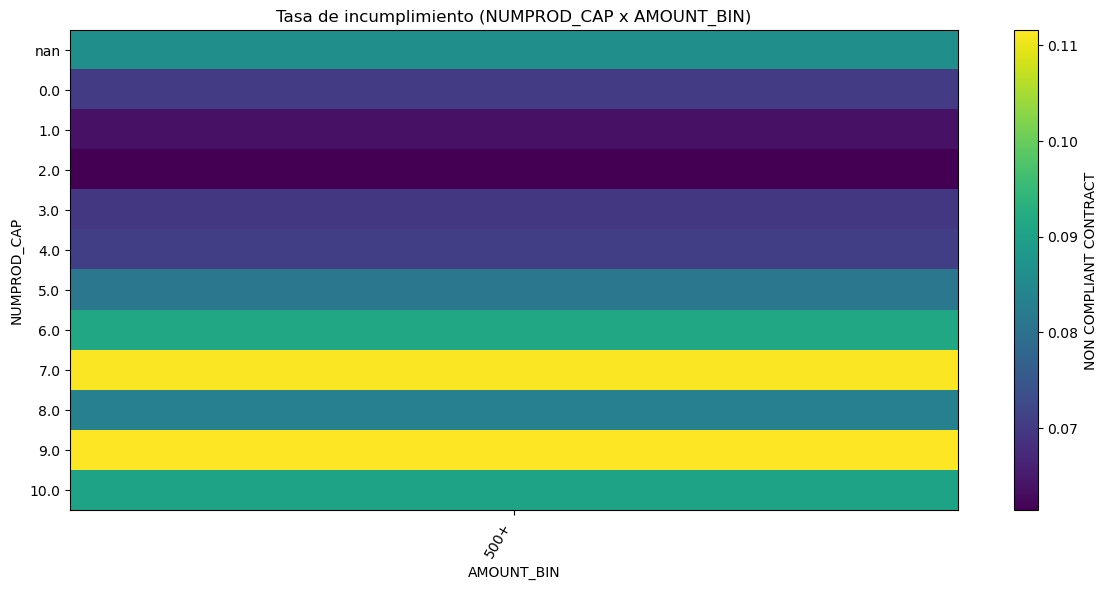

In [6]:
    # --- CELDA 5: Reporte Gráfico (Heatmap) ---
print_header("3. Reporte Gráfico: Heatmap de Incumplimiento")

generate_pivot_and_heatmap(
    df, 
    index_col='NUMPROD_CAP', 
    columns_col='AMOUNT_BIN', 
    value_col='NON_COMPLIANT_CONTRACT', # Este es el valor de la tasa de incumplimiento
    title='Tasa de incumplimiento (NUMPROD_CAP x AMOUNT_BIN)'
)
#

In [8]:
# --- CELDA 6: Guardar Features Finales ---
print_header("4. Guardando Features Finales")

write_parquet(df, cfg.FINAL_FEATURES_PATH, mode="overwrite")
print(f"Features finales (con ratios, bins y CAQ) guardados en: {cfg.FINAL_FEATURES_PATH}")


4. Guardando Features Finales


AttributeError: module 'src.config' has no attribute 'FINAL_FEATURES_PATH'

In [ ]:
df_cli = read_parquet(spark, cfg.CLIENTS_PATH_CLEAN)
df_beh = read_parquet(spark, cfg.BEHAVIOURAL_PATH_CLEAN)

to_csv_via_pandas(df_cli, cfg.CLIENTS_CSV_CLEAN, index=False)
to_csv_via_pandas(df_beh, cfg.BEHAVIOURAL_CSV_CLEAN, index=False)  